# Hotel booking
---

### Segmentation question (RQ1)

**Can we identify distinct booking behaviour profiles from hotel reservation records, using only information available at booking time?**

- Unit of analysis: one row = one booking
- Index time: the moment the booking is created
- Any feature only known after arrival or cancellation is excluded from clustering inputs

In [1]:
import hashlib
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [ ]:
FAST_MODE  = True
FAST_N     = 5_000
FAST_SEED  = 42

SEEDS    = [0, 1, 2, 3, 4]   # fixed seeds for all experiments

PROJECT_ROOT = Path('..').resolve()
DATA_CSV     = PROJECT_ROOT / 'data' / 'raw' / 'hotel_bookings_course_release_v1.csv'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
TABLES_DIR   = PROJECT_ROOT / 'tables'
EXP_CSV      = PROJECT_ROOT / 'experiments.csv'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Data file    :', DATA_CSV)
print('Data exists  :', DATA_CSV.exists())
print('Fast mode    :', FAST_MODE)

Project root : C:\Projects\ANSup\ANSup-hotel-project
Data file    : C:\Projects\ANSup\ANSup-hotel-project\data\raw\hotel_bookings_course_release_v1.csv
Data exists  : True
Fast mode    : True


---
## 1. Data loading and integrity check

In [3]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

EXPECTED_SHA256 = '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06'

actual = sha256(DATA_CSV)
assert actual == EXPECTED_SHA256, (
    f'Checksum mismatch!\n  expected: {EXPECTED_SHA256}\n  got: {actual}'
)
print('SHA-256 OK:', actual)

SHA-256 OK: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06


In [4]:
df_raw = pd.read_csv(DATA_CSV)
print('Shape:', df_raw.shape)
print('\nDtype counts:')
print(df_raw.dtypes.value_counts())
df_raw.head(3)

Shape: (119390, 32)

Dtype counts:
int64      16
str        12
float64     4
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02


In [5]:
if FAST_MODE:
    df = df_raw.sample(n=FAST_N, random_state=FAST_SEED).reset_index(drop=True)
    print(f'[FAST MODE] Subsampled to {len(df)} rows (seed={FAST_SEED})')
else:
    df = df_raw.copy()
    print(f'[FULL MODE] Using all {len(df)} rows')

[FAST MODE] Subsampled to 5000 rows (seed=42)


---
## 2. Exploratory data analysis

### 2.1 Missingness

In [6]:
missing = (
    df.isnull().sum()
    .rename('n_missing')
    .to_frame()
    .assign(pct=lambda x: (x['n_missing'] / len(df) * 100).round(2))
    .query('n_missing > 0')
    .sort_values('pct', ascending=False)
)
print('Columns with missing values:')
display(missing)

Columns with missing values:


,n_missing,pct
company,4731,94.6200
agent,670,13.4000
country,27,0.5400


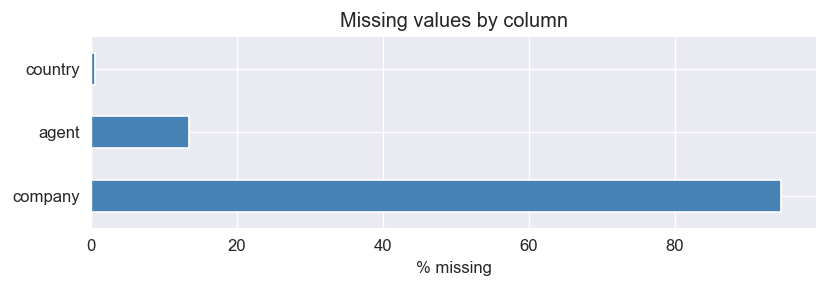

In [7]:
if not missing.empty:
    fig, ax = plt.subplots(figsize=(7, 2.5))
    missing['pct'].plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('% missing')
    ax.set_title('Missing values by column')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eda_missing.png')
    plt.show()

**Missingness takeaways:**  
`company` and `agent` have high emptiness and carry no real behavioural signal, since they're internal IDs, we exclude them. `country` is almost complete, a simple `'Unknown'` fill before grouping is sufficient.

### 2.2 Outliers (IQR method)

In [ ]:
def iqr_outlier_report(df, cols):
    rows = []
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        rows.append({
            'column': c, 'q1': q1, 'q3': q3,
            'lower_fence': lo, 'upper_fence': hi,
            'n_outliers': n_out,
            'pct_outliers': round(n_out / len(df) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

num_cols_raw = df.select_dtypes(include='number').columns.tolist()
outlier_report = iqr_outlier_report(df, num_cols_raw)
display(outlier_report)

**Outlier takeaways:**  
Most "outliers" here are artefacts of sparse, heavily-skewed integer columns where IQR = 0: `adults` , `booking_changes`, `children` etc. These are deviations from a dominant mode. The only column with genuine extremes is `adr` (high-rate bookings). Since we're using `StandardScaler`, outliers get compressed rather than removed, so no clipping needed at this stage.

### 2.3 Numerical distributions

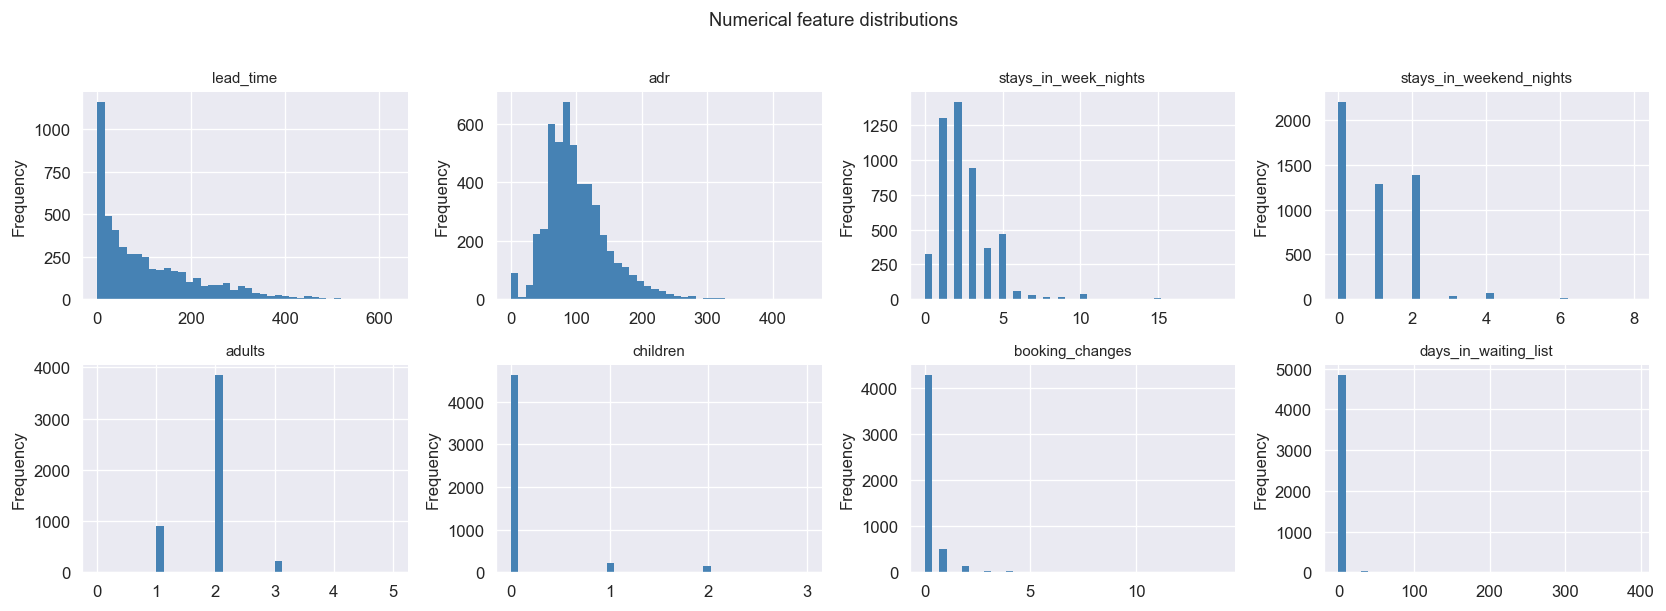

In [9]:
plot_num = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
            'adults', 'children', 'booking_changes', 'days_in_waiting_list']

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, col in zip(axes.flat, plot_num):
    df[col].dropna().plot.hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Numerical feature distributions', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numerical_distributions.png', bbox_inches='tight')
plt.show()

**Distribution takeaways:**  
Most numerical features are near-zero concentrated. `lead_time` and `adr` have long tails, most bookings are last-minute and mid-range, but there's a meaningful tail of far-in-advance, high-spend bookings. `stays_in_week_nights` peaks at 2–3 nights. `children`, `babies`, `booking_changes`, and `days_in_waiting_list` are all dominated by zero. These distributions motivate standardisation over min-max scaling

### 2.4 Categorical features

In [10]:
cat_cols_raw = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns and cardinality:')
for c in cat_cols_raw:
    print(f'  {c:45s} {df[c].nunique():4d} unique')

Categorical columns and cardinality:
  hotel                                            2 unique
  arrival_date_month                              12 unique
  meal                                             5 unique
  country                                         93 unique
  market_segment                                   7 unique
  distribution_channel                             4 unique
  reserved_room_type                               8 unique
  assigned_room_type                              10 unique
  deposit_type                                     3 unique
  customer_type                                    4 unique
  reservation_status                               3 unique
  reservation_status_date                        821 unique


In [11]:
country_counts = df['country'].value_counts()
for n in [5, 10, 15, 20]:
    cov = country_counts.head(n).sum() / country_counts.sum() * 100
    print(f'  Top {n:2d} countries -> {cov:.1f}% of bookings')

  Top  5 countries -> 73.6% of bookings
  Top 10 countries -> 85.1% of bookings
  Top 15 countries -> 91.0% of bookings
  Top 20 countries -> 94.6% of bookings


**Country grouping takeaways:**  
The top 15 countries already cover 91% of bookings. Beyond that, coverage gains diminish quickly. We'll keep the top 15 explicitly and collapse the rest into `'Other'`, keeping dimensionality manageable without losing meaningful geographic signal.

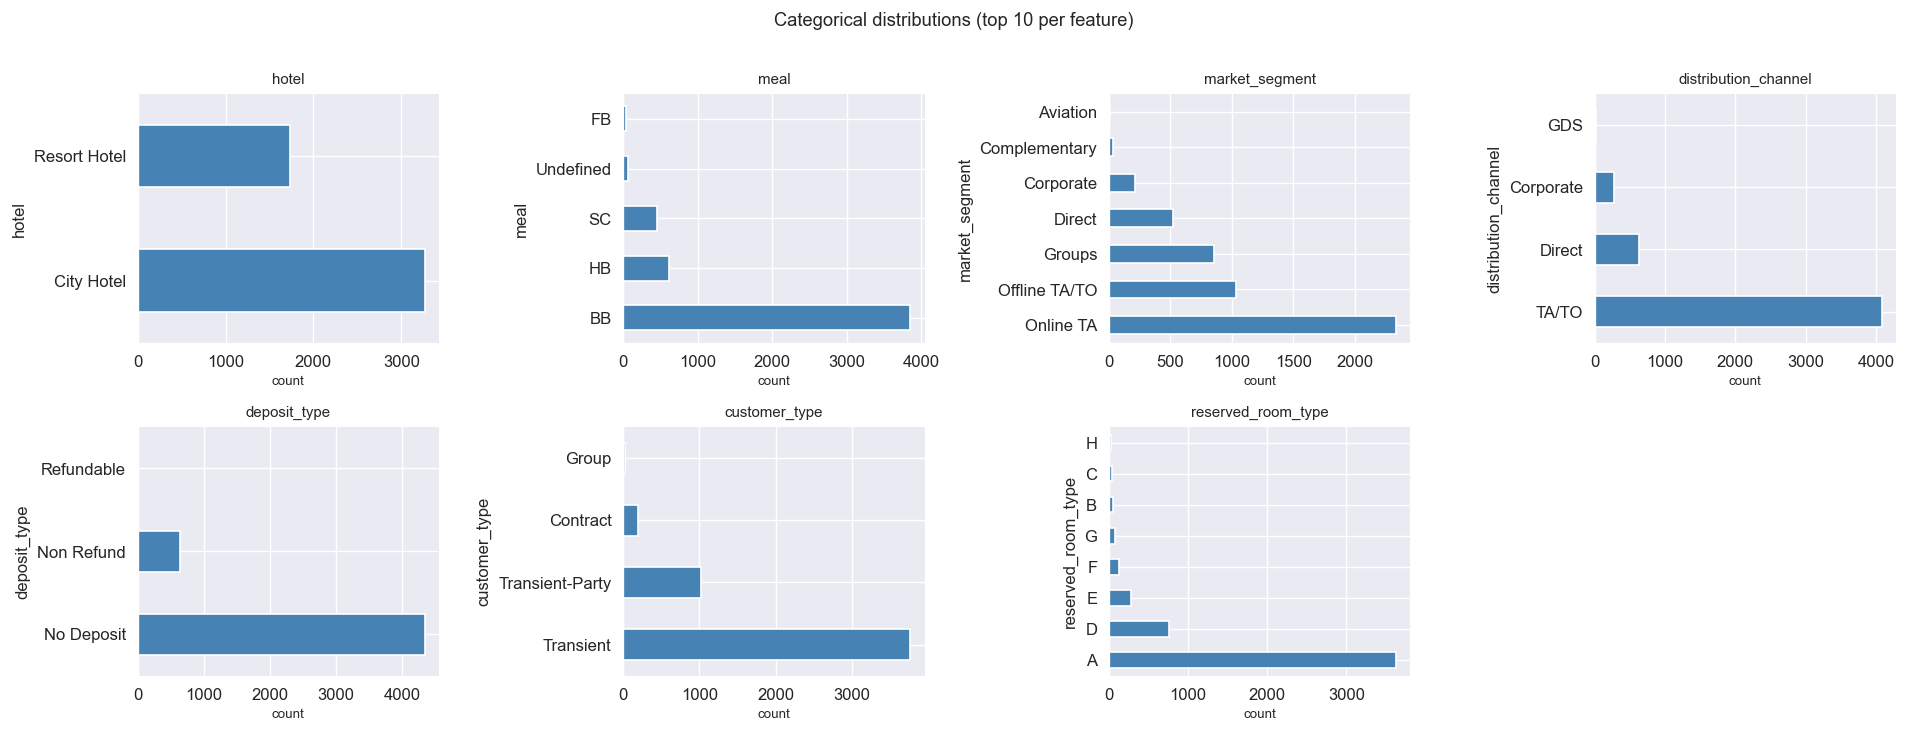

In [12]:
plot_cats = ['hotel', 'meal', 'market_segment', 'distribution_channel',
             'deposit_type', 'customer_type', 'reserved_room_type']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, plot_cats):
    df[col].value_counts().head(10).plot.barh(ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('count', fontsize=8)
axes.flat[-1].set_visible(False)
plt.suptitle('Categorical distributions (top 10 per feature)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Categorical distributions takeaways:**  
Several features are heavily concentrated in a single category. `deposit_type` is almost entirely "No Deposit", which makes it a near-constant and therefore weak discriminator. `meal` is dominated by BB, `customer_type` by Transient, and `reserved_room_type` by type A. `market_segment` shows more spread, with Online TA and Offline TA/TO as the main channels. The practical consequence is that many OHE columns will be near-zero for most observations, contributing little to cluster separation while still adding dimensions to the distance space.

### 2.5 Correlation matrix (numerical)

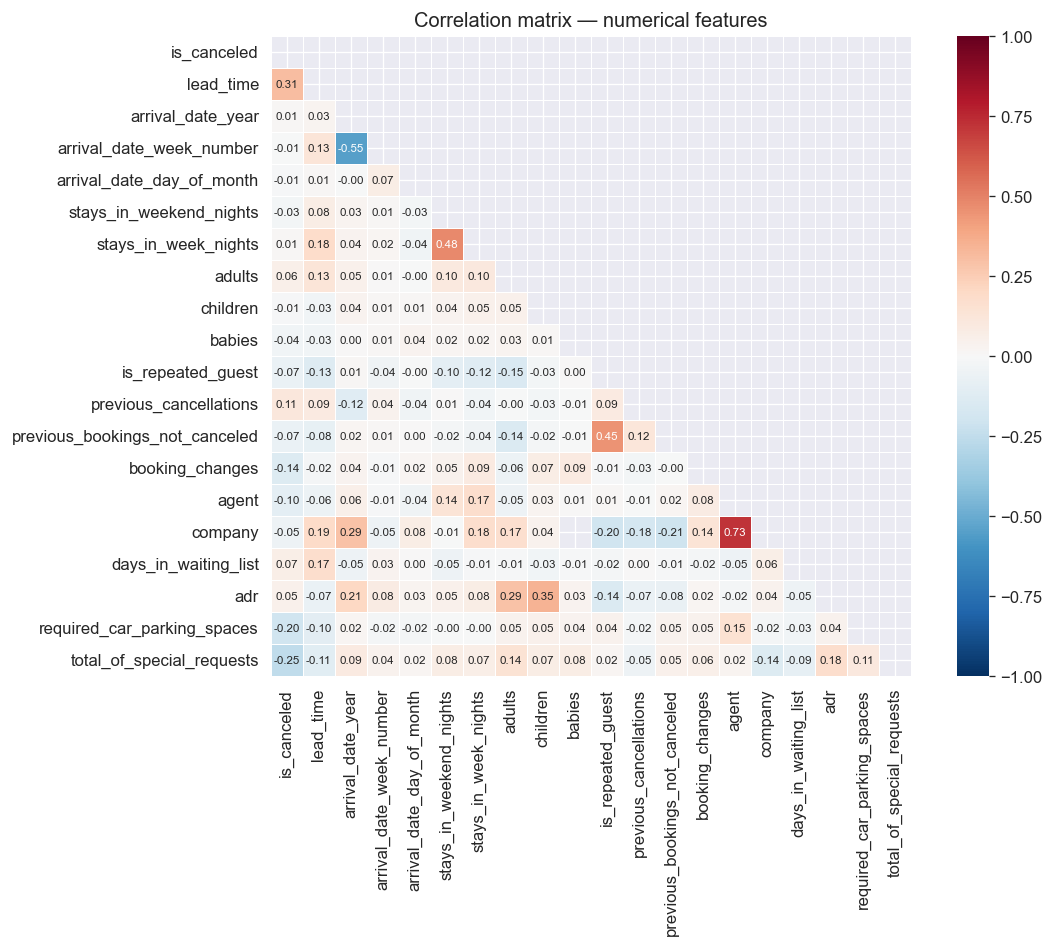

In [13]:
corr = df[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, square=True, ax=ax)
ax.set_title('Correlation matrix — numerical features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

**Correlation takeaways:**  
Multicollinearity is generally low across the features used for clustering. The most notable pairs are:

- `stays_in_weekend_nights` / `stays_in_week_nights`: moderately correlated as expected, but they capture distinct stay patterns (short city break vs longer week trip) so both are kept
- `adr` / `stays_in_week_nights` and `adr` / `adults`: longer stays and larger parties tend to pay more; `adr` carries real signal
- `previous_bookings_not_canceled` / `previous_cancellations`: both reflect guest activity volume rather than reliability, so they are not redundant
- `arrival_date_year` and `arrival_date_week_number`: is explained by the fact that the dataset only covers July 2015 to August 2017, so 2015 has only late year weeks and 2017 only early year weeks, creating an artificial negative association. Since `arrival_date_year` carries no guest behaviour signal, it's a candidate for exclusion.
- `company` / `agent`: strongly correlated but both excluded anyway. `is_canceled` correlations are shown for context only, it's a leakage column and will not enter the clustering pipeline.

---
## 3. Feature governance

**Leakage exclusions** — only available after the booking event, not at index time:

| Column | Reason |
|--------|--------|
| `is_canceled` | outcome of the booking; not known at booking time |
| `reservation_status` | post-arrival status |
| `reservation_status_date` | date of that status change |

**Governance exclusions** — ID-like, no segmentation signal:

| Column | Reason |
|--------|--------|
| `agent` | travel agent ID; >90% missing; not a behaviour feature |
| `company` | company ID; >90% missing; not a behaviour feature |

In [14]:
LEAKAGE_COLS = ['is_canceled', 'reservation_status', 'reservation_status_date']
EXCLUDE_COLS = ['agent', 'company']
DROP_COLS    = LEAKAGE_COLS + EXCLUDE_COLS

df_input = df.drop(columns=DROP_COLS)

NUMERICAL_FEATURES   = df_input.select_dtypes(include='number').columns.tolist()
CATEGORICAL_FEATURES = df_input.select_dtypes(include='object').columns.tolist()

print(f'Numerical features   ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')

Numerical features   (17): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical features (10): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


---
## 4. Preprocessing pipeline (Task 1.1)

Two branches inside a `ColumnTransformer`:
- **Numerical**: median imputation -> `StandardScaler`
- **Categorical**: constant imputation (`'Unknown'`) -> rare-category grouper (< 50 occurrences -> `'Other'`) -> `OneHotEncoder`

Output is a dense float matrix in Euclidean space, compatible with k-means.

In [15]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Replace categories with fewer than min_freq training occurrences with 'Other'."""

    def __init__(self, min_freq=50):
        self.min_freq = min_freq

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.keep_ = [
            set(col.value_counts()[col.value_counts() >= self.min_freq].index)
            for _, col in X.items()
        ]
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for i, (col_name, col) in enumerate(X.items()):
            X[col_name] = col.where(col.isin(self.keep_[i]), other='Other')
        return X.values

In [16]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('grouper', RareCategoryGrouper(min_freq=50)),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUMERICAL_FEATURES),
    ('cat', cat_pipeline, CATEGORICAL_FEATURES),
])

In [32]:
X = preprocessor.fit_transform(df_input)

cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = NUMERICAL_FEATURES + list(cat_names)

print('Transformed matrix shape:', X.shape)
print(f'  Numerical : {len(NUMERICAL_FEATURES)}')
print(f'  After OHE : {len(cat_names)}')
print(f'  Total     : {X.shape[1]}')

if np.isnan(X).any():
    print('NaNs found')
else:
    print('No NaNs found')

Transformed matrix shape: (5000, 82)
  Numerical : 17
  After OHE : 65
  Total     : 82
No NaNs found


In [18]:
pd.Series(feature_names, name='feature').to_frame()

,feature
0,lead_time
1,arrival_date_year
2,arrival_date_week_number
3,arrival_date_day_of_month
4,stays_in_weekend_nights
...,...
77,deposit_type_Other
78,customer_type_Contract
79,customer_type_Other
80,customer_type_Transient


**Preprocessing output takeaways:**  
The final matrix has 82 dimensions — 17 numerical and 65 binary OHE columns. OHE dominates (~79% of features), which means Euclidean distances in this space are heavily influenced by categorical structure. This is expected and acceptable for k-means, but it's something to monitor: a booking that differs on many categorical dummies will appear "far" even if its numerical profile is similar. No NaNs confirm the imputation steps worked correctly.

---
## Task 1.2 Baseline clustering
